# EpiCoV EDA for 2025

- Number of sequences: `50,000`
- Collection date range: 1 Jan 2025 to 12 Mar 2025
- Submission date range: 6 Jan 2025 to 27 Jun 2025

In [1]:
# General
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Custom helpers
from utils import (standardize_country_name, get_continent, choropleth_continent,
choropleth_world, map_age_to_group, col_fillna, plot_dominant_choropleth)

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "~/gcs-buckets"
YEAR = "2025"
PLOTS_PATH = "epicov2025_plots/1Jan25_30Apr25_collection/"

In [3]:
%%time
FILEPATH = os.path.join(DATA_PATH, "1Jan25_30Apr25_collected.csv")
params = {"filepath_or_buffer":FILEPATH, "sep": "," if FILEPATH.endswith(".csv") else "\t"}
df = pd.read_csv(**params)
df.sort_values(by=["Collection date"], inplace=True)
num_rows = 50000
if df.shape[0] > num_rows:
    print(f"Limiting dataset to first {num_rows} rows for testing.")
    df = df.iloc[:num_rows, :]
df.shape, df.info()

Limiting dataset to first 50000 rows for testing.
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 47072 to 57705
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Accession ID                     50000 non-null  object
 1   Submission date                  50000 non-null  object
 2   Virus name                       50000 non-null  object
 3   Collection date                  50000 non-null  object
 4   Location                         50000 non-null  object
 5   Host                             50000 non-null  object
 6   Additional location information  379 non-null    object
 7   Sampling strategy                18833 non-null  object
 8   Gender                           50000 non-null  object
 9   Patient age                      50000 non-null  object
 10  Patient status                   50000 non-null  object
 11  Last vaccinated                  417 non-nul

((50000, 18), None)

In [4]:
df["Submission date"] = pd.to_datetime(df["Submission date"], format="mixed")
df["Submission date"].min(), df["Submission date"].max()

(Timestamp('2025-01-06 00:00:00'), Timestamp('2025-06-27 00:00:00'))

In [5]:
df["submission_yr"] = df["Submission date"].dt.strftime("%Y")
df["submission_yr"].value_counts().sort_index()

submission_yr
2025    50000
Name: count, dtype: int64

In [6]:
df["Collection date"] = pd.to_datetime(df["Collection date"], format="mixed")
df["Collection date"].min(), df["Collection date"].max()

(Timestamp('2025-01-01 00:00:00'), Timestamp('2025-03-12 00:00:00'))

In [7]:
df["collection_yr"] = df["Collection date"].dt.strftime("%Y")
df["collection_yr"].value_counts().sort_index()

collection_yr
2025    50000
Name: count, dtype: int64

Let us validate if `Submission_date` is after the `Collection_date`

In [8]:
df[df["Collection date"] > df["Submission date"]].shape

(0, 20)

Find average time between collection of sample and submission of sequence collected on or after Jan 2020

In [9]:
df = df[df["Collection date"] >= pd.to_datetime("2020-01-01")]
df["collection_to_submission_days"] = (df["Submission date"] - df["Collection date"]).dt.days
df["collection_to_submission_days"].describe()

count    50000.000000
mean        37.014560
std         32.724652
min          1.000000
25%         16.000000
50%         24.000000
75%         45.000000
max        177.000000
Name: collection_to_submission_days, dtype: float64

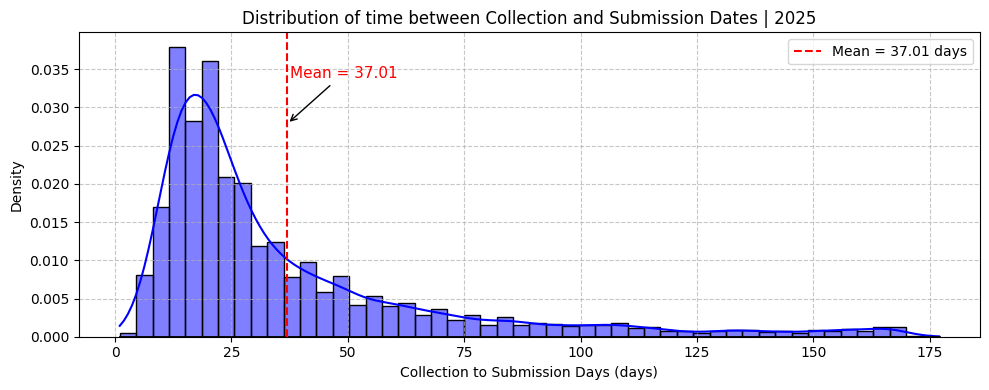

In [10]:
plt.figure(figsize=(10, 4))
sns.histplot(df["collection_to_submission_days"], bins=50, kde=True, color='blue', stat='density')
sns.lineplot(x=sorted(df["collection_to_submission_days"]), 
             y=np.full(df.shape[0], 0), color='black', linewidth=2)
mean_days = df["collection_to_submission_days"].mean()
plt.axvline(mean_days, color='red', linestyle='--', label=f"Mean = {mean_days:.2f} days")

# Place annotation above the mean line, at the top of the plot
ymax = plt.gca().get_ylim()[1]
plt.annotate(f"Mean = {mean_days:.2f}", xy=(mean_days, ymax*0.7), xytext=(mean_days+0.5, ymax*0.85),
             arrowprops=dict(facecolor='red', arrowstyle='->'), color='red', fontsize=11)

plt.xlabel("Collection to Submission Days (days)")
plt.title(f"Distribution of time between Collection and Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_to_submission_days_distribution_{YEAR}.png"), dpi=300)
plt.show()

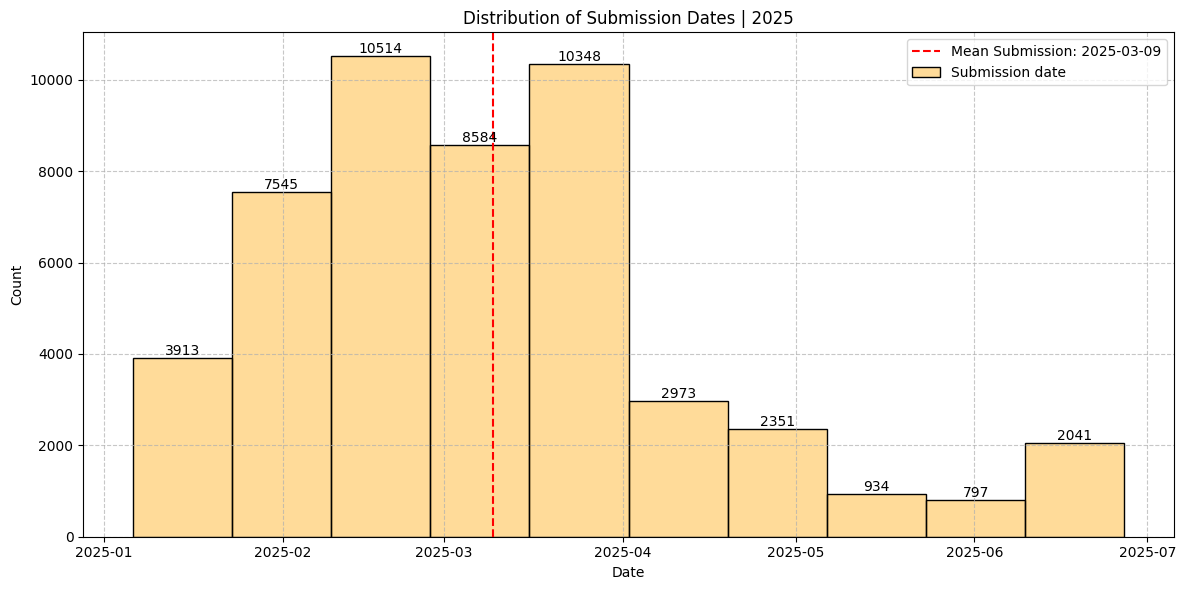

In [11]:
plt.figure(figsize=(12, 6))

# Plot histograms for submission dates
sns.histplot(df["Submission date"], bins=10, color="orange", label="Submission date", kde=False, alpha=0.4)

# Calculate means
mean_submission = df["Submission date"].mean()

# Plot mean lines
plt.axvline(mean_submission, color="red", linestyle="--", label=f"Mean Submission: {mean_submission.date()}")

# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"submission_dates_spread_{YEAR}.png"), dpi=300)
plt.show()

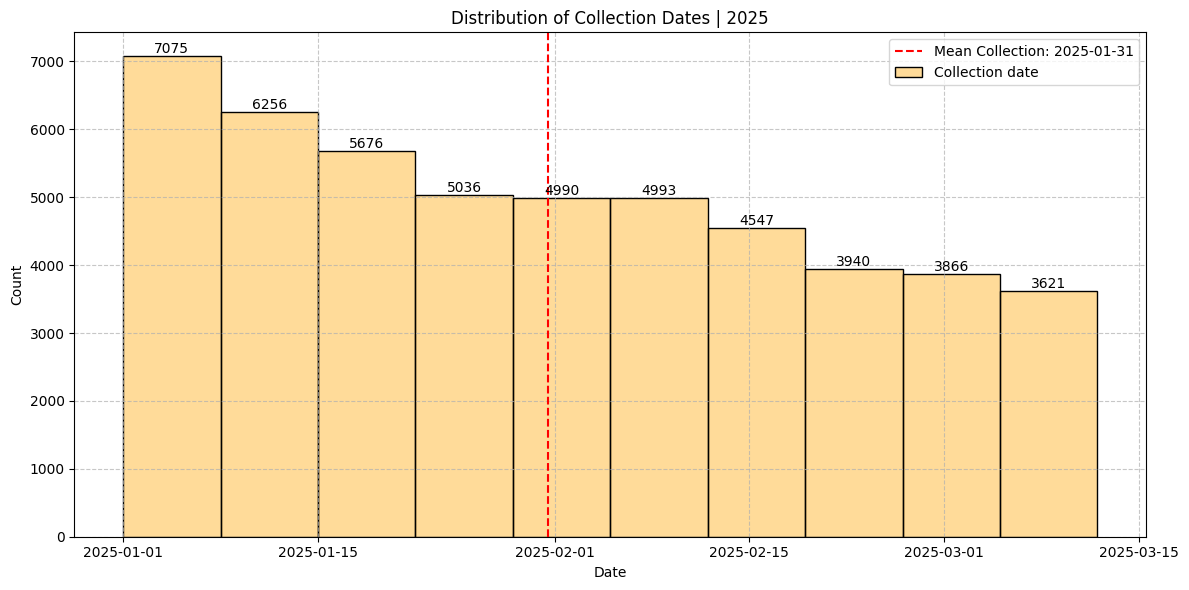

In [12]:
plt.figure(figsize=(12, 6))

# Plot histograms for collection dates
sns.histplot(df["Collection date"], bins=10, color="orange", label="Collection date", kde=False, alpha=0.4)

# Calculate means
mean_collection = df["Collection date"].mean()

# Plot mean lines
plt.axvline(mean_collection, color="red", linestyle="--", label=f"Mean Collection: {mean_collection.date()}")

# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Collection Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_dates_spread_{YEAR}.png"), dpi=300)
plt.show()

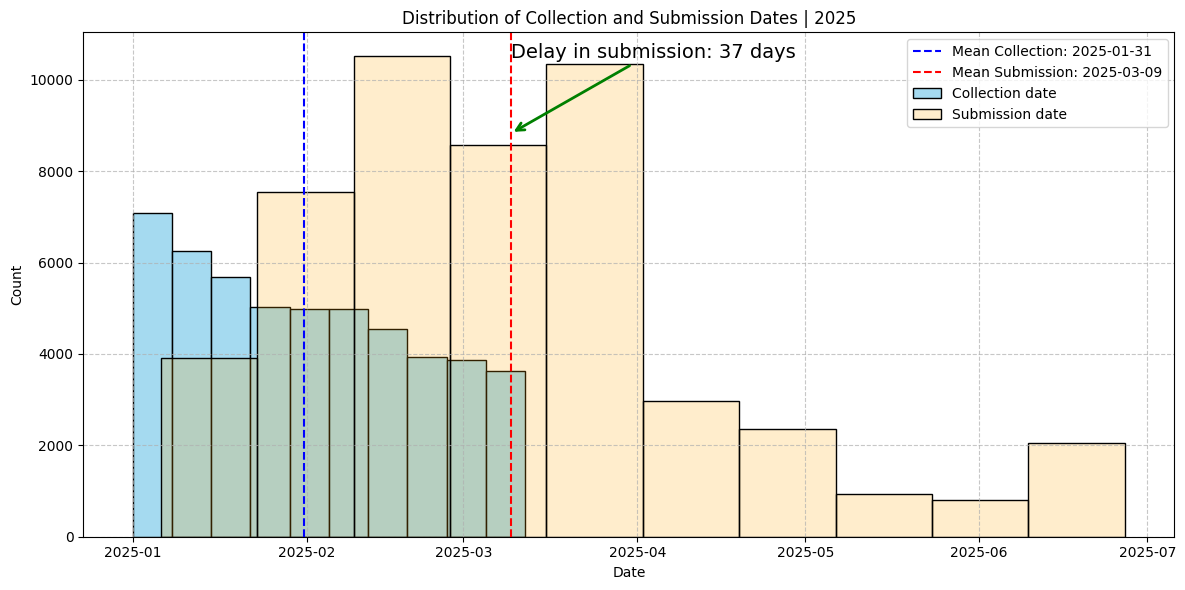

In [13]:
plt.figure(figsize=(12, 6))

# Plot histograms for collection and submission dates
sns.histplot(df["Collection date"], bins=10, color="skyblue", label="Collection date", kde=False)
sns.histplot(df["Submission date"], bins=10, color="orange", label="Submission date", kde=False, alpha=0.2)

# Calculate means
mean_collection = df["Collection date"].mean()
mean_submission = df["Submission date"].mean()

# Plot mean lines
plt.axvline(mean_collection, color="blue", linestyle="--", label=f"Mean Collection: {mean_collection.date()}")
plt.axvline(mean_submission, color="red", linestyle="--", label=f"Mean Submission: {mean_submission.date()}")

# Annotate lead time
lead_time = (mean_submission - mean_collection).days
plt.annotate(
    f"Delay in submission: {lead_time} days",
    xy=(mean_submission, plt.ylim()[1]*0.8),
    xytext=(mean_submission, plt.ylim()[1]*0.95),
    arrowprops=dict(facecolor='green', edgecolor='green', arrowstyle='->', lw=2),
    color="black",
    fontsize=14,
    ha='left'
)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Collection and Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_submission_dates_distribution_{YEAR}.png"), dpi=300)
plt.show()

In [14]:
df["Gender"].value_counts()

Gender
unknown                   26221
Female                    13561
Male                      10166
unknow                       36
73                            2
69                            2
5 m                           2
not collected                 1
45                            1
93                            1
Non-binary/trans other        1
83                            1
72                            1
94                            1
65                            1
77                            1
96                            1
Name: count, dtype: int64

In [15]:
df["Patient status"].value_counts()

Patient status
unknown                    48291
Live                         554
Hospitalized                 302
Symptomatic                  226
Alive                        148
Released                     113
live                          97
Ambulatory                    39
hospitalized                  37
Asymptomatic; Recovered       32
Non hospitalized              32
non hospitalized              30
SRAG                          19
Asymptomatic                  17
Sentinela                     14
Outpatient                    11
Deceased                       8
not collected                  5
Severe; Recovered              4
unkown                         4
Released, Live                 4
Severe                         4
Death                          3
Non-hospitalized               2
Asymptomatic; Deceased         2
In patient                     1
Recovered                      1
Name: count, dtype: int64

In [16]:
df["Patient age"].value_counts()

Patient age
unknown        24140
85-89           1001
90-94            828
80-84            810
0                707
               ...  
41-46              1
20-25              1
30 years           1
64-69 years        1
25 years           1
Name: count, Length: 419, dtype: int64

In [17]:
df[~df["Gender"].isin(["Male", "Female", "unknown", "unknow", "not collected", "Non-binary/trans other"])]

,Accession ID,Submission date,Virus name,Collection date,Location,Host,Additional location information,Sampling strategy,Gender,Patient age,...,Last vaccinated,Passage,Specimen,Additional host information,Lineage,Clade,AA Substitutions,submission_yr,collection_yr,collection_to_submission_days
36087,EPI_ISL_19751062,2025-02-26,hCoV-19/Spain/CB-HUMV-5424315/2025,2025-01-17,Europe / Spain / Cantabria,Human,NaN,NaN,73,Female,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(NSP5_P132H,Spike_H69del,NSP3_G489S,Spike_L24d...",2025,2025,40
32440,EPI_ISL_19751061,2025-02-26,hCoV-19/Spain/CB-HUMV-5424388/2025,2025-01-18,Europe / Spain / Cantabria,Human,NaN,NaN,45,Male,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(Spike_H69del,NSP3_G489S,Spike_L24del,NSP4_T32...",2025,2025,39
55423,EPI_ISL_19751060,2025-02-26,hCoV-19/Spain/CB-HUMV-8812596/2025,2025-01-24,Europe / Spain / Cantabria,Human,NaN,NaN,93,Female,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(NSP5_P132H,Spike_H69del,NSP3_T1465I,Spike_L24...",2025,2025,33
55424,EPI_ISL_19751059,2025-02-26,hCoV-19/Spain/CB-HUMV-8817108/2025,2025-01-30,Europe / Spain / Cantabria,Human,NaN,NaN,73,Female,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(Spike_H69del,NSP3_G489S,Spike_L24del,NSP4_T32...",2025,2025,27
52546,EPI_ISL_19751058,2025-02-26,hCoV-19/Spain/CB-HUMV-5431271/2025,2025-01-31,Europe / Spain / Cantabria,Human,NaN,NaN,5 m,Male,...,NaN,Original,NaN,NaN,JN.1,GRA,"(Spike_H69del,NS7b_F19L,Spike_S50L,NSP3_G489S,...",2025,2025,26
25851,EPI_ISL_19751057,2025-02-26,hCoV-19/Spain/CB-HUMV-8822025/2025,2025-02-03,Europe / Spain / Cantabria,Human,NaN,NaN,72,Male,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(Spike_H69del,NSP3_G489S,Spike_L24del,NSP4_T32...",2025,2025,23
27922,EPI_ISL_19751056,2025-02-26,hCoV-19/Spain/CB-HUMV-5447091/2025,2025-02-05,Europe / Spain / Cantabria,Human,NaN,NaN,69,Male,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(NSP5_P132H,Spike_H69del,Spike_L24del,NSP3_G48...",2025,2025,21
27921,EPI_ISL_19751055,2025-02-26,hCoV-19/Spain/CB-HUMV-5431716/2025,2025-02-06,Europe / Spain / Cantabria,Human,NaN,NaN,5 m,Male,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(NSP5_P132H,Spike_H69del,NSP3_G489S,Spike_L24d...",2025,2025,20
27917,EPI_ISL_19751051,2025-02-26,hCoV-19/Spain/CB-HUMV-21761119/2025,2025-02-07,Europe / Spain / Cantabria,Human,NaN,NaN,83,Female,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(Spike_H69del,NSP3_G489S,Spike_L24del,NSP4_T32...",2025,2025,19
27920,EPI_ISL_19751054,2025-02-26,hCoV-19/Spain/CB-HUMV-5447216/2025,2025-02-08,Europe / Spain / Cantabria,Human,NaN,NaN,94,Female,...,NaN,Original,NaN,NaN,XEC (consensus call),GRA,"(NSP5_P132H,Spike_H69del,NSP3_G489S,Spike_L24d...",2025,2025,18


In [18]:
# Swap the two values in these rows (Patient age and Patent gender)
for i, row in df[~df["Gender"].isin(["Male", "Female", "unknown", "unknow", "not collected", "Non-binary/trans other"])].iterrows():
    age = row["Patient age"]
    df.at[i, "Patient age"] = row["Gender"]
    df.at[i, "Gender"] = age

In [19]:
df["Gender"].value_counts()

Gender
unknown                   26221
Female                    13568
Male                      10173
unknow                       36
not collected                 1
Non-binary/trans other        1
Name: count, dtype: int64

## Geographical distribution

Let's see the geographical distribution of various parameters

In [20]:
(print(set([x.split("/")[0] for x in df["Location"].values.tolist()])), df.nunique())

{'Oceania ', 'South America ', 'North America ', 'Africa ', 'Asia ', 'Europe '}


(None,
 Accession ID                       50000
 Submission date                      154
 Virus name                         50000
 Collection date                       71
 Location                            1349
 Host                                   1
 Additional location information      126
 Sampling strategy                     51
 Gender                                 6
 Patient age                          418
 Patient status                        27
 Last vaccinated                      256
 Passage                                8
 Specimen                              67
 Additional host information          269
 Lineage                              712
 Clade                                  5
 AA Substitutions                   48506
 submission_yr                          1
 collection_yr                          1
 collection_to_submission_days        175
 dtype: int64)

Collate required columns

In [21]:
df1 = df[["Accession ID", "Location", "Gender", "Patient age", "Patient status"]].reset_index(drop=True)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Accession ID    50000 non-null  object
 1   Location        50000 non-null  object
 2   Gender          50000 non-null  object
 3   Patient age     50000 non-null  object
 4   Patient status  50000 non-null  object
dtypes: object(5)
memory usage: 1.9+ MB


Split location into `continent`, `country`, `state` and `city`

In [22]:
df1["continent"], df1["country"], df1["state"], df1["city"] = np.nan, np.nan, np.nan, np.nan

cols = ["continent", "country", "state", "city"]
for i, row in tqdm(df1.iterrows(), desc="Geographical information extraction", total=df1.shape[0]):
    loc = row["Location"]
    locs = [x.strip() for x in loc.split("/")]
    for j in range(min(len(locs),len(cols))):
        df1.loc[i, cols[j]] = locs[j]
df1.drop(columns=["Location"], inplace=True)
df1.info()

Geographical information extraction: 100%|██████████| 50000/50000 [00:50<00:00, 989.96it/s] 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Accession ID    50000 non-null  object
 1   Gender          50000 non-null  object
 2   Patient age     50000 non-null  object
 3   Patient status  50000 non-null  object
 4   continent       50000 non-null  object
 5   country         50000 non-null  object
 6   state           46665 non-null  object
 7   city            11211 non-null  object
dtypes: object(8)
memory usage: 3.1+ MB


## Entries distribution countrywise

We look at number of entries from each country normalised by:
- country's population
- country's per capita income
- reported cases
- reported deaths

First let's create a dictionary containing country's metadata

In [23]:
df1["country"].nunique()

80

Countrywise population for 2025 from [Worldometer](https://www.worldometers.info/world-population/population-by-country/)

In [24]:
df_pop = pd.read_csv(os.path.join(DATA_PATH, "worldometer_population_by_country_2025.csv"))
df_pop.rename(columns={"Country (or dependency)": "country", "Population (2025)": "2025"}, inplace=True)
df_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          233 non-null    object 
 1   2025             233 non-null    int64  
 2   Yearly Change    233 non-null    object 
 3   Net Change       233 non-null    object 
 4   Density (P/Km²)  233 non-null    int64  
 5   Land Area (Km²)  233 non-null    int64  
 6   Migrants (net)   233 non-null    object 
 7   Fert. Rate       233 non-null    float64
 8   Median Age       233 non-null    float64
 9   Urban Pop %      210 non-null    object 
 10  World Share      233 non-null    object 
dtypes: float64(2), int64(3), object(6)
memory usage: 20.2+ KB


In [25]:
(len(set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist())),
 set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist()))

(4, {'Canary Islands', 'Cote d’Ivoire', 'Curacao', 'USA'})

In [26]:
focus = list(set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist()))
df1[df1["country"].isin(focus)]["country"].value_counts()

country
USA               21788
Canary Islands       31
Cote d’Ivoire         8
Curacao               4
Name: count, dtype: int64

A few countries like South Korea, Czech Republic etc have different alternative names used in the dataframes. Let us standardize it using the following snippet.

In [27]:
df1["country"] = df1["country"].str.replace("USA", "United States")
df1["country"] = df1["country"].str.replace("Cote d’Ivoire", "Cote d'Ivoire")

In [28]:
df_pop["country"] = df_pop["country"].str.replace("Côte d'Ivoire", "Cote d'Ivoire")
df_pop["country"] = df_pop["country"].str.replace("Curaçao", "Curacao")

In [29]:
countries = df1["country"].unique()
country_meta = [{"country":x} for x in countries]
len(country_meta), country_meta[:3]

(80,
 [{'country': 'Canada'}, {'country': 'United States'}, {'country': 'Brazil'}])

In [30]:
focus = list(set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist()))
df1[df1["country"].isin(focus)].shape[0], df1[df1["country"].isin(focus)]["country"].value_counts()

(31,
 country
 Canary Islands    31
 Name: count, dtype: int64)

Population of Canary Islands is part of that of Spain - how to deal?

In [31]:
# Fill in population data in country_meta
for x in tqdm(country_meta, desc="Filling population data"):
    country = x["country"]
    cont = df1[df1["country"]==country]["continent"].values[0]
    x["continent"] = cont
    if country in df_pop["country"].values.tolist():
        pop = df_pop[df_pop["country"]==country][YEAR].values[0]
        x["population"] = int(pop)
    elif country in ["Canary Islands","Crimea"]:
        x["population"] = float("NaN")
country_meta[:3]

Filling population data: 100%|██████████| 80/80 [00:01<00:00, 74.10it/s]


[{'country': 'Canada', 'continent': 'North America', 'population': 40126723},
 {'country': 'United States',
  'continent': 'North America',
  'population': 347275807},
 {'country': 'Brazil', 'continent': 'South America', 'population': 212812405}]

Collect only entries where population is non-zero => exclude Canary Islands as of now

In [32]:
skip_countries = ["Canary Islands", "Crimea"]
df2 = df1[~df1["country"].isin(skip_countries)]
df1.shape, df2.shape

((50000, 8), (49969, 8))

### A. Normalising by country's population
#### A.1. Number of entries from each country

Let's first see how many entries are from different countries grouped by their continent

In [33]:
df_country = pd.DataFrame([x for x in country_meta if x["country"] not in ["Canary Islands","Crimea"]])
df_country.shape, df_country[df_country["population"].isnull()].shape

((79, 3), (0, 3))

In [34]:
sorted(df_pop["country"].unique().tolist())

['Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Caribbean Netherlands',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic (Czechia)',
 'DR Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Eswatini',
 'Ethiopia',
 'Faeroe Islands',
 'Falkland Islands',
 'Fi

In [35]:
exclude = ["Africa (UN)", "Asia (UN)", "Americas (UN)", "Europe (UN)",
            "Oceania (UN)", "World", "High-income countries", "Land-locked developing countries (LLDC)",
            "Latin America and the Caribbean (UN)", "Least developed countries", "Less developed regions",
            "Less developed regions, excluding China", "Less developed regions, excluding least developed countries",
            "Low-income countries", "Lower-middle-income countries", "More developed regions", "Northern America (UN)",
            "Small island developing states (SIDS)", "Upper-middle-income countries"]
df_pop = df_pop[~df_pop["country"].isin(exclude)]
df_pop["country"].nunique()

233

In [36]:
df_merged = pd.merge(df_country, df_pop[["country", YEAR]], on="country", how="right")
df_merged.rename(columns={YEAR: f"population_{YEAR}"}, inplace=True)
df_merged.drop(columns=["population"], inplace=True)
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          233 non-null    object
 1   continent        79 non-null     object
 2   population_2025  233 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 5.6+ KB


In [37]:
df_merged["country_standard"] = df_merged["country"].apply(standardize_country_name)
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           233 non-null    object
 1   continent         79 non-null     object
 2   population_2025   233 non-null    int64 
 3   country_standard  233 non-null    object
dtypes: int64(1), object(3)
memory usage: 7.4+ KB


In [38]:
df_merged["continent_x"] = df_merged["country_standard"].apply(get_continent)
df_merged["continent_x"].nunique(), df_merged["continent"].nunique()

(7, 6)

In [39]:
df_merged[df_merged["continent_x"]=="Unknown"]

,country,continent,population_2025,country_standard,continent_x
8,Russia,Europe,143997393,Russia,Unknown
14,DR Congo,NaN,112832473,DR Congo,Unknown
17,Turkey,Asia,87685426,Turkey,Unknown
91,Czech Republic (Czechia),NaN,10609239,Czech Republic (Czechia),Unknown
154,Timor-Leste,NaN,1418517,Timor-Leste,Unknown
170,Western Sahara,NaN,600904,Western Sahara,Unknown
174,Brunei,NaN,466330,Brunei,Unknown
194,Micronesia,NaN,113683,Micronesia,Unknown
197,St. Vincent & Grenadines,NaN,99924,St. Vincent & Grenadines,Unknown
199,U.S. Virgin Islands,NaN,84138,U.S. Virgin Islands,Unknown


In [40]:
for i, row in df_merged.iterrows():
    if row["continent_x"] == "Unknown" and not pd.isnull(row["continent"]):
        df_merged.at[i, "continent_x"] = row["continent"]
    
    if pd.isnull(row["continent"]) and row["continent_x"] != "Unknown":
        df_merged.at[i, "continent"] = row["continent_x"]

In [41]:
df_merged["continent"].unique(), df_merged["continent_x"].unique()

(array(['Asia', 'North America', 'Africa', 'South America', 'Europe', nan,
        'Oceania'], dtype=object),
 array(['Asia', 'North America', 'Africa', 'South America', 'Europe',
        'Unknown', 'Oceania'], dtype=object))

In [42]:
df_merged[df_merged["continent"].isna()]

,country,continent,population_2025,country_standard,continent_x
14,DR Congo,NaN,112832473,DR Congo,Unknown
91,Czech Republic (Czechia),NaN,10609239,Czech Republic (Czechia),Unknown
154,Timor-Leste,NaN,1418517,Timor-Leste,Unknown
170,Western Sahara,NaN,600904,Western Sahara,Unknown
174,Brunei,NaN,466330,Brunei,Unknown
194,Micronesia,NaN,113683,Micronesia,Unknown
197,St. Vincent & Grenadines,NaN,99924,St. Vincent & Grenadines,Unknown
199,U.S. Virgin Islands,NaN,84138,U.S. Virgin Islands,Unknown
210,Sint Maarten,NaN,43923,Sint Maarten,Unknown
218,Caribbean Netherlands,NaN,31338,Caribbean Netherlands,Unknown


In [43]:
for i, row in df_merged.iterrows():
    if row["continent_x"] != "Unknown" and not pd.isnull(row["continent"]):
        if row["continent"] != row["continent_x"]:
            print(f"Mismatch at index {i}: {row['country']} - {row['continent']} vs {row['continent_x']}")

Mismatch at index 188: Curacao - South America vs North America


We do the following assignment (based on Google search):

- `Azerbaijan` mostly in Western Asia. So we assign `Asia`
- `Curacao` is in `South America`
- `Cyprus` is in `Europe`

In [44]:
df_merged.loc[int(df_merged.index[df_merged["country"]=="Azerbaijan"][0]), "continent"] = "Asia"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Curacao"][0]), "continent_x"] = "South America"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Cyprus"][0]), "continent_x"] = "Europe"

In [45]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           233 non-null    object
 1   continent         221 non-null    object
 2   population_2025   233 non-null    int64 
 3   country_standard  233 non-null    object
 4   continent_x       233 non-null    object
dtypes: int64(1), object(4)
memory usage: 9.2+ KB


9 of the 237 entries have `Unknown` continent. Let's see which countries are these.

In [46]:
df_merged[df_merged["continent_x"] == "Unknown"]

,country,continent,population_2025,country_standard,continent_x
14,DR Congo,NaN,112832473,DR Congo,Unknown
91,Czech Republic (Czechia),NaN,10609239,Czech Republic (Czechia),Unknown
154,Timor-Leste,NaN,1418517,Timor-Leste,Unknown
170,Western Sahara,NaN,600904,Western Sahara,Unknown
174,Brunei,NaN,466330,Brunei,Unknown
194,Micronesia,NaN,113683,Micronesia,Unknown
197,St. Vincent & Grenadines,NaN,99924,St. Vincent & Grenadines,Unknown
199,U.S. Virgin Islands,NaN,84138,U.S. Virgin Islands,Unknown
210,Sint Maarten,NaN,43923,Sint Maarten,Unknown
218,Caribbean Netherlands,NaN,31338,Caribbean Netherlands,Unknown


Let's ignore these regions for now.

In [47]:
for i, row in df_merged.iterrows():
    if row["continent_x"] != "Unknown" and not pd.isnull(row["continent"]):
        if row["continent"] != row["continent_x"]:
            print(f"Mismatch at index {i}: {row['country']} - {row['continent']} vs {row['continent_x']}")

Mismatch at index 155: Cyprus - Asia vs Europe


In [48]:
df_merged = df_merged[df_merged["continent_x"] != "Unknown"].drop(columns=["continent_x"])
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221 entries, 0 to 231
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           221 non-null    object
 1   continent         221 non-null    object
 2   population_2025   221 non-null    int64 
 3   country_standard  221 non-null    object
dtypes: int64(1), object(3)
memory usage: 8.6+ KB


In [49]:
# Insert a new row for Antarctica into df_merged
antarctica_row = {
    "country": "Antarctica",
    "continent": "Antarctica",
    f"population_{YEAR}": 0,
    "country_standard": "Antarctica",
}
df_merged = pd.concat([df_merged, pd.DataFrame([antarctica_row])], ignore_index=True)
df_merged.tail()

,country,continent,population_2025,country_standard
217,Montserrat,North America,4359,Montserrat
218,Falkland Islands,Europe,3469,Åland Islands
219,Tokelau,Oceania,2608,Tokelau
220,Niue,Oceania,1821,Niue
221,Antarctica,Antarctica,0,Antarctica


In [50]:
df_merged["num_entries"] = float("NaN")

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        df_merged.loc[i, "num_entries"] = df2[df2["country"]==country].shape[0]
df_merged["num_entries"].describe()

count       79.000000
mean       632.518987
std       2654.640020
min          1.000000
25%          6.500000
50%         44.000000
75%        281.500000
max      21788.000000
Name: num_entries, dtype: float64

Now, we normalize the number of entries by the population of the country to get the comparison to be in a level playing field

In [51]:
# per lakh population
df_merged["num_entries_per_lakh"] = df_merged["num_entries"] / (df_merged[f"population_{YEAR}"] / 1e5)
df_merged.head()

,country,continent,population_2025,country_standard,num_entries,num_entries_per_lakh
0,India,Asia,1463865525,India,10.0,0.000683
1,China,Asia,1416096094,China,284.0,0.020055
2,United States,North America,347275807,United States,21788.0,6.273976
3,Indonesia,Asia,285721236,Indonesia,6.0,0.002100
4,Pakistan,Asia,255219554,Pakistan,2.0,0.000784


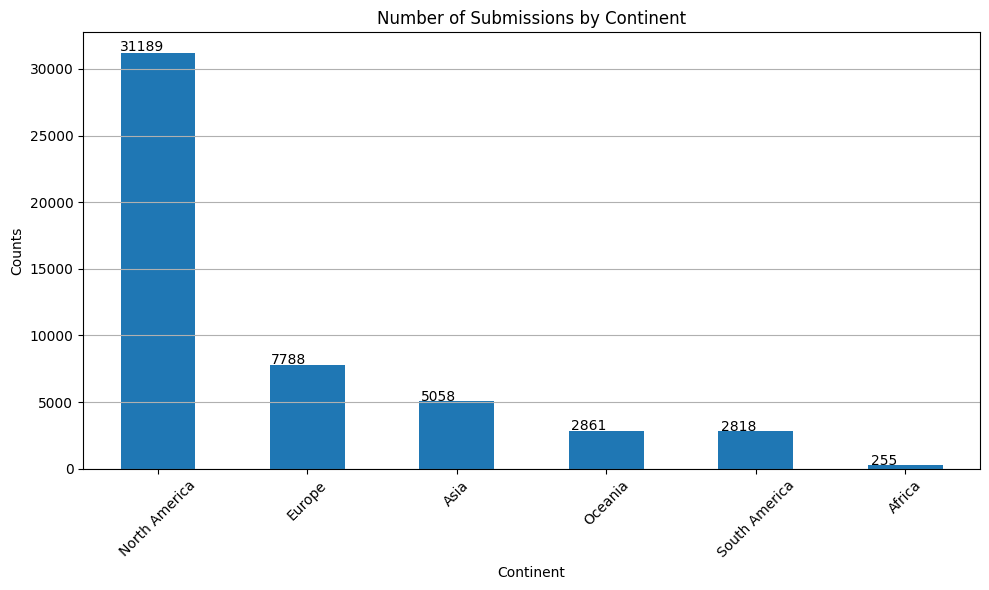

In [52]:
# Plot the bar chart
ax = df2["continent"].value_counts().plot(kind='bar', figsize=(10, 6))
plt.grid()

# Annotate the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.xlabel('Continent')
plt.xticks(rotation=45)
plt.ylabel('Counts')
plt.title('Number of Submissions by Continent')
plt.grid(axis= 'x')
plt.tight_layout()
plt.show()

In [53]:
df_merged["log_num_entries_per_lakh"] = np.log10(df_merged["num_entries_per_lakh"].replace(0, np.nan))
df_merged["log_num_entries_per_lakh"].describe()

count    79.000000
mean     -0.517666
std       1.140825
min      -3.165501
25%      -1.364604
50%      -0.428380
75%       0.393004
max       1.694832
Name: log_num_entries_per_lakh, dtype: float64

In [54]:
sign = -1 if df_merged["log_num_entries_per_lakh"].min() < 0 else 1
df_merged["log_num_entries_per_lakh"] = df_merged["log_num_entries_per_lakh"] + (df_merged["log_num_entries_per_lakh"].min() * sign)
df_merged["log_num_entries_per_lakh"].describe()

count    79.000000
mean      2.647835
std       1.140825
min       0.000000
25%       1.800897
50%       2.737121
75%       3.558505
max       4.860333
Name: log_num_entries_per_lakh, dtype: float64

In [55]:
# Fill NaN values with a sentinel value (e.g., 0) for visualization purposes
df_merged = col_fillna(df_merged, "log_num_entries_per_lakh", -1.0) # fill with -1.0 for NaN values

custom_scale = [
    [0.0, "#d3d3d3"],    # NaN or sentinel value -> grey (to be masked in z values)
    [0.0001, "#313695"],  # dark blue for low log values
    [0.25,   "#74add1"],  # light blue
    [0.5,    "#ffffbf"],  # yellow (neutral / zero)
    [0.75,   "#f46d43"],  # orange
    [1.0,    "#a50026"]   # dark red for high log values
]

fig = choropleth_world(df_merged,
                        value_column='log_num_entries_per_lakh',
                        color_scale=custom_scale,
                        title=f'Submissions per Lakh Population (World) | Log 10 Scale | {YEAR}',
                        label='Submissions/Lakh (Log 10)',
                        hover_data={
                            f'population_{YEAR}': True,
                            'num_entries': True,
                            'country': False
                        })
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_entries_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

Plot per‐continent maps

In [56]:
# Define custom color scale including a gray value for the sentinel
custom_scale = [
    [0.0, "#d3d3d3"],    # NaN or sentinel value -> grey (to be masked in z values)
    [0.0001, "#313695"],  # dark blue for low log values
    [0.25,   "#74add1"],  # light blue
    [0.5,    "#ffffbf"],  # yellow (neutral / zero)
    [0.75,   "#f46d43"],  # orange
    [1.0,    "#a50026"]   # dark red for high log values
]

fig = choropleth_continent(df_merged,
                           value_column='log_num_entries_per_lakh',
                           color_scale=custom_scale,
                           title=f'Submissions per 1 Lakh Population by Continent | Log 10 Scale | {YEAR}',
                           label='Submissions/Lakh (Log 10)',
                           YEAR=YEAR
                           )
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_entries_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

#### A.2. Gender distribution across countries

Let's next look at the gender distribution across countries again grouped by continents

In [57]:
df_merged["gender_m_per_lakh"], df_merged["gender_f_per_lakh"], df_merged["gender_u_per_lakh"] = float('nan'), float('nan'), float('nan')

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        # Calculate
        df_merged.loc[i, "gender_m_per_lakh"] = (df2[(df2["country"] == country) & (df2["Gender"] == "Male")].shape[0])/(row[f"population_{YEAR}"] / 1e5)
        df_merged.loc[i, "gender_f_per_lakh"] = (df2[(df2["country"] == country) & (df2["Gender"] == "Female")].shape[0])/(row[f"population_{YEAR}"] / 1e5)
        df_merged.loc[i, "gender_u_per_lakh"] = (df2[(df2["country"] == country) & (df2["Gender"] == "unknown")].shape[0])/(row[f"population_{YEAR}"] / 1e5)

Convert to log 10 scale to show variation

In [58]:
df_merged["log_gender_m_per_lakh"] = np.log10(df_merged["gender_m_per_lakh"].replace(0, np.nan))
df_merged["log_gender_m_per_lakh"].describe()

count    59.000000
mean     -1.095963
std       1.053568
min      -3.320403
25%      -1.680188
50%      -1.067757
75%      -0.380175
max       1.294307
Name: log_gender_m_per_lakh, dtype: float64

In [59]:
sign = -1 if df_merged["log_gender_m_per_lakh"].min() < 0 else 1
df_merged["log_gender_m_per_lakh"] = df_merged["log_gender_m_per_lakh"] + (df_merged["log_gender_m_per_lakh"].min() * sign)
df_merged["log_gender_m_per_lakh"].describe()

count    59.000000
mean      2.224440
std       1.053568
min       0.000000
25%       1.640215
50%       2.252646
75%       2.940228
max       4.614710
Name: log_gender_m_per_lakh, dtype: float64

For choropleth maps, its better to have 3 different maps one for each gender. First we look at a zoomed out view of the whole world

In [60]:
# World map - distribution of males
df_merged = col_fillna(df_merged, "log_gender_m_per_lakh", -1.0) # fill with -1.0 for NaN values

# Define custom color scale including a gray value for the sentinel
male_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#cbdbfc"],  # very light blue
    [0.01, "#c6dbef"],
    [0.03, "#b3d1e6"],
    [0.06, "#9ecae1"],
    [0.12, "#6bb8d6"],
    [0.25, "#3182bd"],
    [0.5, "#08519c"],
    [1.0, "#08306b"]      # darkest blue
]


fig = choropleth_world(df_merged,
                       value_column="log_gender_m_per_lakh",
                       color_scale=male_scale,
                       title=f"Number of submissions from Males per Lakh Population (World) | Log 10 Scale | {YEAR}",
                       label="Males/1 lakh (Log 10)",
                       hover_data={
                            'gender_m_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_males_per_lakh_log10_world_{YEAR}.html"))
fig.show()

Now we do for the entries submitted by females

In [61]:
df_merged["log_gender_f_per_lakh"] = np.log10(df_merged["gender_f_per_lakh"].replace(0, np.nan))
df_merged["log_gender_f_per_lakh"].describe()

count    62.000000
mean     -1.084512
std       1.102485
min      -3.688380
25%      -1.789765
50%      -1.187606
75%      -0.291957
max       1.472553
Name: log_gender_f_per_lakh, dtype: float64

In [62]:
sign = -1 if df_merged["log_gender_f_per_lakh"].min() < 0 else 1
df_merged["log_gender_f_per_lakh"] = df_merged["log_gender_f_per_lakh"] + (df_merged["log_gender_f_per_lakh"].min() * sign)
df_merged["log_gender_f_per_lakh"].describe()

count    62.000000
mean      2.603868
std       1.102485
min       0.000000
25%       1.898615
50%       2.500774
75%       3.396423
max       5.160933
Name: log_gender_f_per_lakh, dtype: float64

In [63]:
# World map - distribution of females
df_merged = col_fillna(df_merged, "log_gender_f_per_lakh", -1.0) # fill with -1.0 for NaN values

# Define custom color scale including a gray value for the sentinel
female_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#ffb2d5"],  # very light pink
    [0.01, "#ffafcb"],
    [0.05, "#fa9fb5"],
    [0.1, "#f768a1"],
    [0.2, "#c51b8a"],
    [0.4, "#ae017e"],
    [1.0, "#7a0177"]   # darkest pink
]

fig = choropleth_world(df_merged,
                       value_column="log_gender_f_per_lakh",
                       color_scale=female_scale,
                       title=f"Number of submissions from Females per Lakh Population (World) | Log 10 Scale | {YEAR}",
                       label="Females/1 lakh (Log 10)",
                       hover_data={
                            'gender_f_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_females_per_lakh_log10_world_{YEAR}.html"))
fig.show()

In [64]:
df_merged["log_gender_u_per_lakh"] = np.log10(df_merged["gender_u_per_lakh"].replace(0, np.nan))
df_merged["log_gender_u_per_lakh"].describe()

count    37.000000
mean     -0.417914
std       1.101034
min      -2.510192
25%      -1.524334
50%      -0.170388
75%       0.398139
max       1.034080
Name: log_gender_u_per_lakh, dtype: float64

In [65]:
sign = -1 if df_merged["log_gender_u_per_lakh"].min() < 0 else 1
df_merged["log_gender_u_per_lakh"] = df_merged["log_gender_u_per_lakh"] + (df_merged["log_gender_u_per_lakh"].min() * sign)
df_merged["log_gender_u_per_lakh"].describe()

count    37.000000
mean      2.092277
std       1.101034
min       0.000000
25%       0.985858
50%       2.339804
75%       2.908331
max       3.544272
Name: log_gender_u_per_lakh, dtype: float64

In [66]:
# World map - distribution of females
df_merged = col_fillna(df_merged, "log_gender_u_per_lakh", -1.0) # fill with -1.0 for NaN values

# Define custom color scale including a gray value for the sentinel
unknown_scale = [
    [0.0, "#d3d3d3"],    # missing -> light grey
    [0.0001, "#fff7e6"], # very pale tan
    [0.001, "#fee8c8"],  # very light tan
    [0.01, "#fdd49e"],   # light tan-orange
    [0.05, "#fdbb84"],   # medium golden tan
    [0.1, "#fdae6b"],    # deeper orange
    [0.2, "#fd8d3c"],    # orange
    [0.4, "#e6550d"],    # brown-orange
    [0.7, "#b35806"],    # brown
    [1.0, "#543005"]     # darkest brown
]

fig = choropleth_world(df_merged,
                       value_column="log_gender_u_per_lakh",
                       color_scale=unknown_scale,
                       title=f"Number of Unknown gender per Lakh Population (World) | Log 10 Scale | {YEAR}",
                       label="Missing gender/1 Lakh (Log 10)",
                       hover_data={
                            'gender_u_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_unknown_gender_per_lakh_log10_world_{YEAR}.html"))
fig.show()

Now we plot the continent-wise choropleth maps

In [67]:
fig = choropleth_continent(df_merged,
                           value_column='log_gender_m_per_lakh',
                           color_scale=male_scale,
                           title=f"Number of Submissions from males per Lakh Population by Continent | Log 10 Scale | {YEAR}",
                           label="Males/1 Lakh (Log 10)",
                           YEAR = YEAR,
                           )

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_males_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

In [68]:
fig = choropleth_continent(df_merged,
                           value_column='log_gender_f_per_lakh',
                           color_scale=female_scale,
                           title=f"Number of Submissions from females per Lakh Population by Continent | Log 10 Scale | {YEAR}",
                           label="Females/1 Lakh (Log 10)",
                           YEAR=YEAR,
                           )

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_females_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

In [69]:
fig = choropleth_continent(df_merged,
                           value_column='log_gender_u_per_lakh',
                           color_scale=unknown_scale,
                           title=f"Number of Submissions with missing gender per Lakh Population by Continent | Log 10 Scale | {YEAR}",
                           label="Unknown gender/1 Lakh (Log 10)",
                           YEAR=YEAR,
                           )

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_unknown_gender_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

Let's see how the gender ratio is across continents and countries

In [70]:
df_merged["male_female_ratio"] = df_merged["gender_m_per_lakh"] / df_merged["gender_f_per_lakh"].replace(0, np.nan)
df_merged["male_female_ratio"].describe()

count    62.000000
mean      0.895654
std       0.648376
min       0.000000
25%       0.510542
50%       0.882836
75%       1.008947
max       4.200000
Name: male_female_ratio, dtype: float64

In [71]:
df_merged = col_fillna(df_merged, "male_female_ratio", -1.0) # fill with -1.0 for NaN values

custom_rdbu_with_gray = [
    [0.0, "#d3d3d3"],     # Missing / -1 → light gray
    [0.05, "#67001f"],    # Deep red (now at low end)
    [0.1, "#b2182b"],     # Red
    [0.33, "#f7f7f7"],    # White (neutral)
    [0.66, "#2166ac"],    # Blue
    [1.0, "#053061"]      # Deep blue (now at high end)
]

fig = choropleth_world(df_merged,
                       value_column="male_female_ratio",
                       color_scale=custom_rdbu_with_gray,
                       title=f"Male to Female ratio in total submissions (World) | {YEAR}",
                       label="Gender ratio",
                       hover_data={
                            'male_female_ratio': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_male_female_ratio_world_{YEAR}.html"))
fig.show()

In [72]:
fig = choropleth_continent(df_merged,
                           value_column='male_female_ratio',
                           color_scale=custom_rdbu_with_gray,
                           title="Male to Female ratio in total submissions (continent)",
                           label="Gender ratio",
                            hover_data={"male_female_ratio": True,
                                        f"population_{YEAR}": True,
                                        "country": False},
                            YEAR=YEAR
                           )
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_male_female_ratio_continents_{YEAR}.html"))
fig.show()

Let us also see which gender submitted majority of the entries for each country on an absolute scale.

In [73]:
fig = plot_dominant_choropleth(
        df2,
        value_column='Gender',
        color_map={
            'Male': '#1f77b4',   # blue
            'Female': "#ff2eb9",   # pink,
            'unknown':'#bdbdbd',  # gray for unknown
            'unknow':'#bdbdbd'  # gray for unknown
        },
        title="Majority Gender"
    )
fig.show()

#### A.3. Patient status distribution across countries

Let's next look at the patient status distribution across countries again grouped by continents

In [74]:
len(list(df2["Patient status"].unique())), list(df2["Patient status"].unique())

(27,
 ['unknown',
  'Hospitalized',
  'Live',
  'Symptomatic',
  'Released',
  'Non-hospitalized',
  'hospitalized',
  'live',
  'Asymptomatic; Recovered',
  'non hospitalized',
  'Severe; Recovered',
  'Outpatient',
  'Deceased',
  'not collected',
  'In patient',
  'unkown',
  'Asymptomatic',
  'Non hospitalized',
  'Severe',
  'Ambulatory',
  'Death',
  'Alive',
  'SRAG',
  'Sentinela',
  'Asymptomatic; Deceased',
  'Released, Live',
  'Recovered'])

As we see there are a lot of overlapping categories. Let us group them together into meaningful categories as follows (reference: [WHO](https://onlinelibrary.wiley.com/cms/asset/d557561d-7c41-47f5-a5c6-db79e68988ad/tbed13892-fig-0003-m.jpg))

In [75]:
status_mapping = {
    'unknown': 'Unknown',
    'Symptomatic': 'Ambulatory mild',
    'Oropharyngeal swab': 'Ambulatory mild', # have to confirm
    'Live': 'Uninfected', # have to confirm
    'Hospitalized': 'Hospitalized moderate', # have to confirm
    'Deceased': 'Dead',
    'Inpatient': 'Hospitalized moderate', # have to confirm
    'Released': 'Uninfected', # have to confirm
    'Outpatient': 'Hospitalized moderate', # have to confirm
    'Recovered': 'Uninfected', # have to confirm
    np.nan: 'Unknown',
    'Mild clinical signs without hospitalization': 'Ambulatory mild',
    'Hospitalized (Mild)': 'Hospitalized moderate',
    'Hospitalized (Moderate)': 'Hospitalized moderate',
    'Hospitalized (Severe)': 'Hospitalized severe',
    'Hospitalized (Critical)': 'Hospitalized severe',
    'unknow': 'Unknown',
    'EHPAD': 'Hospitalized severe', # facility designed to accommodate individuals who have lost physical or mental autonomy
    'Discharged': 'Uninfected', # have to confirm
    'Hospitalized, oxygenotherapy, diarrhea': 'Hospitalized moderate',
    'Overseas inflow': 'Hospitalized moderate', # have to confirm
    'Mild': 'Ambulatory mild',
    'Asymptomatic/Released': 'Ambulatory mild',
    'Intensive Care Unit': 'Hospitalized severe',
    'Unknow': 'Unknown',
    'Released, Live': 'Uninfected', # have to confirm
    'Moderate': 'Ambulatory mild',
    'unkown': 'Unknown',
    'Asymptomatic': 'Ambulatory mild',
    'Hospitalized, Released': 'Uninfected', # have to confirm
    'Ambulatory': 'Ambulatory mild',
    'Not Vaccinated': 'Unknown', # have to confirm
    'Nanopore': 'Unknown', # have to confirm
    'Home': 'Unknown', # have to confirm
    'Nasal swab': 'Unknown', # have to confirm
    'Not vaccinated': 'Unknown', # have to confirm
    'mild symptomatic': 'Ambulatory mild',
    'Quarantine': 'Ambulatory mild', # have to confirm
    'Naso-oropharyngeal swab': 'Unknown', # have to confirm
    'Suspected Corona': 'Ambulatory mild', # have to confirm
    'Moderate / Outpatient': 'Ambulatory mild',
    'Hospitalized (Intensive care unit and Released)': 'Hospitalized severe', # have to confirm
    'Not hospitalized': 'Ambulatory mild',
    'alive, no death no hospitalization': 'Uninfected', # have to confirm
    'Hospitalized (Deceased)': 'Dead',
    'No clinical signs': 'Ambulatory mild',
    'Mild symptoms (fever, cardiovascular disorders)': 'Ambulatory mild',
    'Screening': 'Unknown', # have to confirm
    'Unknown': 'Unknown',
    'EHPAD_IRA': 'Hospitalized severe', # facility designed to accommodate individuals who have lost physical or mental autonomy
    'Hospitalized (Live)': 'Hospitalized moderate',
    'Discharged after recovery': 'Uninfected', # have to confirm
    'Severe / ICU': 'Hospitalized severe',
    'Acute upper respiratory infection, unspecified': 'Ambulatory mild',
    'ICD-10 Disease: Z03.8 Observation for other suspected diseases and conditions': 'Ambulatory mild', # have to confirm
    'Contact with and exposure to other communicable diseases': 'Ambulatory mild', # have to confirm
    'Aymptomatic': 'Ambulatory mild',
    'Mild infection': 'Ambulatory mild',
    'Recovering': 'Ambulatory mild', # have to confirm
    'Bronchitis': 'Unknown', # have to confirm
    'Stable in quarantine': 'Ambulatory mild',
    'Epidemiology Study': 'Unknown',
    'Pneumonia (chest X-ray), not critical': 'Hospitalized moderate',
    'Hospitalized (possible MIS-C)': 'Hospitalized moderate', # have to confirm
    'Hospitalized (Released)': 'Uninfected', # have to confirm
    'Hospitalized (Stable)': 'Hospitalized moderate',
    'ICU; Serious': 'Hospitalized severe',
    'Hospitalized (Intensive care unit)': 'Hospitalized severe',
    'Pneumonia (chest X-ray)': 'Hospitalized moderate', # have to confirm
    'Initially hospitalized, but now improved and discharged': 'Uninfected', # have to confirm
    'Reinfection': 'Ambulatory mild',
    'live': 'Uninfected', # have to confirm
    'Severe': 'Hospitalized severe',
    'Alive': 'Uninfected', # have to confirm
    'Asymptomatic, identified as positive during preoperation investigation': 'Ambulatory mild',
    'Live, mild symptoms, at home': 'Ambulatory mild',
    'Mild/Contact exposure/Asymptomatic': 'Ambulatory mild',
    'Death': 'Dead',
    'Severe infection': 'Hospitalized severe',
    'Mild, at home.': 'Ambulatory mild',
    'Lived': 'Uninfected', # have to confirm
    'Mild clinical signs': 'Ambulatory mild',
    'Symptoms indicative of upper respiratory infection': 'Ambulatory mild',
    'Not Hospitalized': 'Ambulatory mild',
    'ICD-10 Disease: J18.1 Lobar pneumonia, unspecified organism': 'Ambulatory mild', # have to confirm
    'Other acute upper respiratory infections of multiple sites': 'Ambulatory mild',
    'Pneumonia, unspecified organism': 'Hospitalized moderate', # have to confirm
    'Acute bronchitis': 'Hospitalized moderate', # have to confirm
    'ICD-10 Disease: J06.9 Acute upper respiratory infection, unspecified': 'Ambulatory mild', # have to confirm
    'Live, acute respiratory infection': 'Ambulatory mild',
    'Live, physical examination': 'Unknown', # have to confirm
    'ICD-10 Disease: J18.9 Pneumonia, unspecified organism': 'Ambulatory mild', # have to confirm
    'hospitalized': 'Hospitalized moderate', # have to confirm
    'Mild / Contact exposure / Asymptomatic': 'Ambulatory mild',
    'Fever': 'Ambulatory mild',
    'moderate symptomatic, hospitalized with oxygen did not require ICU, improvement and then discharge': 'Hospitalized moderate',
    'Isolation': 'Ambulatory mild', # have to confirm
    'Hospitalized, Discharged, Alive': 'Uninfected', # have to confirm
    'Paucisymptomatic': 'Ambulatory mild',
}

Now we apply this mapping to the dataframe

In [76]:
df2['status_category'] = df2['Patient status'].map(status_mapping)
df2['status_category'].value_counts()

status_category
Unknown                  48274
Uninfected                 917
Hospitalized moderate      340
Ambulatory mild            282
Dead                        11
Hospitalized severe          4
Name: count, dtype: int64

In [77]:
score_map = {"Unknown": 0, "Uninfected": 1, "Ambulatory mild": 2, "Hospitalized moderate": 3, "Hospitalized severe": 4, "Dead": 5}

In [78]:
df2["status_score"] = df2['status_category'].map(score_map)
df2["status_score"].describe()

count    49828.000000
mean         0.051618
std          0.326487
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.000000
Name: status_score, dtype: float64

In [79]:
df_merged["status_per_lakh"] = float('nan')

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        # Calculate
        df_merged.loc[i, "status_per_lakh"] = (df2[(df2["country"] == country)]["status_score"].mean())/(row[f"population_{YEAR}"] / 1e5)
df_merged["status_per_lakh"].describe()

count    78.000000
mean      0.001844
std       0.007275
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000004
max       0.055018
Name: status_per_lakh, dtype: float64

In [80]:
df_merged["log_status_per_lakh"] = np.log10(df_merged["status_per_lakh"].replace(0, np.nan))
df_merged["log_status_per_lakh"].describe()

count    21.000000
mean     -2.972691
std       1.224541
min      -6.114619
25%      -3.544475
50%      -2.590846
75%      -2.271560
max      -1.259499
Name: log_status_per_lakh, dtype: float64

In [81]:
sign = -1 if df_merged["log_status_per_lakh"].min() < 0 else 1
df_merged["log_status_per_lakh"] = df_merged["log_status_per_lakh"] + (df_merged["log_status_per_lakh"].min() * sign)
df_merged["log_status_per_lakh"].describe()

count    21.000000
mean      3.141928
std       1.224541
min       0.000000
25%       2.570144
50%       3.523773
75%       3.843059
max       4.855120
Name: log_status_per_lakh, dtype: float64

In [82]:
df_merged = col_fillna(df_merged, "log_status_per_lakh", -1.0) # fill with -1.0 for NaN values

custom_scale = [
    [0.0, "#d3d3d3"],     # NaN or missing → light grey
    [0.0001, "#1a9850"],  # green
    [0.25,   "#a6d96a"],  # light green
    [0.5,    "#ffffbf"],  # yellow
    [0.75,   "#fdae61"],  # orange
    [1.0,    "#a50026"]   # red
]


fig = choropleth_world(df_merged,
                       value_column="log_status_per_lakh",
                       color_scale=custom_scale,
                       title=f"Health status (World) | Log 10 Scale | {YEAR}",
                       label="Avg severity/1 Lakh",
                       hover_data={
                            'status_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_health_status_per_lakh_log10_world_{YEAR}.html"))
fig.show()

In [83]:
fig = choropleth_continent(df_merged,
                           value_column='log_status_per_lakh',
                           color_scale=custom_scale,
                           title=f"Health status (continents) | Log 10 Scale | {YEAR}",
                           label="Avg health score/1 Lakh (Log 10)",
                            hover_data={"status_per_lakh": True,
                                        f"population_{YEAR}": True,
                                        "country": False},
                            YEAR=YEAR,
                           )
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_health_status_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

### A.4. Age distribution

Let's see what is the age distribution of the patients across each geographical location

In [84]:
df2["Patient age"].unique()

array(['85-89', '66', '2', 'unknown', '0', '14-19', '67', '64', '86',
       '1-6', '81', '26', '60 - 69', '90-94', '39', '28', '41', '57',
       '42', '80 - 89', '1', '>=65', '63', '78', '52', '43', '53',
       '50 - 59', '25', '75-79', '80-84', '59', '45-49', '60', '76',
       '60-64', '89', '22', '70-74', '32', '75', '90', '95', '84',
       '5 months', '80', '38', '30', '45', '50', '62', '82', '10-15',
       '83', '70', '74', '46', '49', '58', '31', '70 - 79', '72', '>90',
       '92', '73', '29', '93', '3', '50-59', '16 months', '79', '80-89',
       '94', '31 months', '77', '88', '37', '27', '60-69', '20-29', '68',
       '0.17', '65', '65-69', '6 months', '70-79', '4 months', '25-29',
       '51', '54', '55-59', '100', '7 months', '87', '44', '55', '35-39',
       '90 - 99', '56', '85', '0-9', '91', '35', '50-54', '15', '85+',
       '98', '61', '20', '20 - 29', '30 - 39', '21', '3 months',
       '9 months', '2 months', '0 - 9', '40 - 49', '8', '36', '20-24',
       '30-34'

The age format reported here is very varied and requires to be standardized. We refer the age brackets and the classification provided by the [Global Burden of Diseases](https://ourworldindata.org/burden-of-disease):

- `< 5` years old
- `5-14` years old
- `15-49` years old
- `50-69` years old
- `> 70` years old

In [85]:
df2['age_group'] = df2['Patient age'].apply(map_age_to_group)

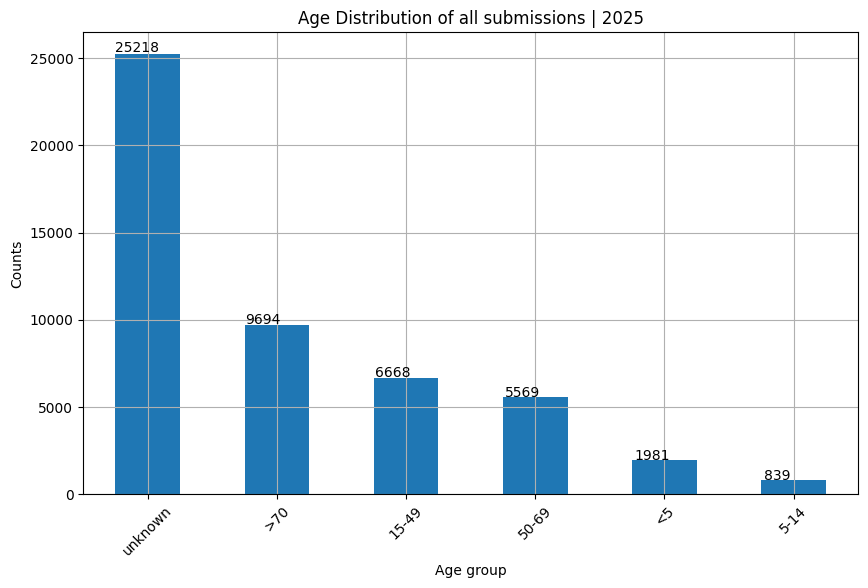

In [86]:
# Plot the bar chart
ax = df2["age_group"].value_counts().plot(kind='bar', figsize=(10, 6))
plt.grid()

# Annotate the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.xlabel('Age group')
plt.xticks(rotation=45)
plt.ylabel('Counts')
plt.title(f'Age Distribution of all submissions | {YEAR}')
plt.show()

In [87]:
import plotly.express as px

df_grouped = df2.groupby(["country", "age_group"]).size().reset_index(name="count")

df_grouped

,country,age_group,count
0,American Samoa,unknown,4
1,Argentina,15-49,13
2,Argentina,5-14,5
3,Argentina,50-69,7
4,Argentina,<5,21
...,...,...,...
269,United States,5-14,536
270,United States,50-69,2298
271,United States,<5,907
272,United States,>70,2164


In [88]:
fig = px.choropleth(
    df_grouped,
    locations="country",
    color="count",
    locationmode="country names",
    animation_frame="age_group",
    color_continuous_scale="YlGnBu",
    title=f"Age Group-wise Entries by Country | {YEAR}"
)
# Adjust the order of labels in the slider
# Desired order: '<5', '5-14', '15-49', '50-69', '>70', 'unknown'
desired_order = ['<5', '5-14', '15-49', '50-69', '>70', 'unknown']

# Find the current order of frames
current_order = [frame.name for frame in fig.frames]

# Create a mapping from label to frame
frame_dict = {frame.name: frame for frame in fig.frames}

# Reorder frames
fig.frames = tuple([frame_dict[label] for label in desired_order if label in frame_dict])

# Update slider steps order
for slider in fig.layout.sliders:
    step_dict = {step['label']: step for step in slider['steps']}
    slider['steps'] = [step_dict[label] for label in desired_order if label in step_dict]

fig.update_layout(title_x=0.5, width=1200, height=700)

fig.show()

In [89]:
fig = plot_dominant_choropleth(
    df2,
    value_column='age_group',
    color_map={
        '<5': '#e5f5e0',      # light green
        '5-14': '#a1d99b',
        '15-49': '#41ab5d',   # more contrast
        '50-69': '#238b45',   # more contrast
        '>70': '#005824',     # darkest green for high contrast
        'unknown': '#bdbdbd'  # gray for unknown
    },
    title="Dominant Age Group (Green Shades)",
    year=YEAR,
    )
fig.show()

In [90]:
df_merged.groupby("continent").agg({"num_entries_per_lakh":"mean","gender_m_per_lakh":"mean","gender_f_per_lakh":"mean",
                                    "gender_u_per_lakh":"mean","male_female_ratio":"mean", "status_per_lakh":"mean",})

,num_entries_per_lakh,gender_m_per_lakh,gender_f_per_lakh,gender_u_per_lakh,male_female_ratio,status_per_lakh
continent,,,,,,
Africa,0.598456,0.251855,0.345694,0.000906,0.608817,0.001554
Antarctica,NaN,NaN,NaN,NaN,NaN,NaN
Asia,0.998786,0.104031,0.091882,0.795085,1.030843,0.002917
Europe,3.599808,1.209995,1.584213,0.805600,1.006338,0.000764
North America,3.901506,1.285013,1.930838,0.685590,0.647880,0.004038
Oceania,6.951161,0.769636,0.970648,5.210878,0.936449,0.000000
South America,1.848358,0.268941,0.306679,1.272738,0.915120,0.001791
